In [1]:
import os
import torch.nn.functional as F
import pandas as pd
import itertools
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from src.ties_merging_utils import *


sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('./src'))


In [2]:
def load_all_vectors(models, datasets, vector_types, seeds, base_dir="./vectors"):
    loaded_data = {}
    
    for v_type in vector_types:
        for model in models:
            for dataset in datasets:
                for seed in seeds:
                    path = f"{base_dir}/{v_type}/{model}/{dataset}/{seed}/vector.pt"
                        
                    if os.path.exists(path):
                        vec_sd = torch.load(path, map_location='cpu', weights_only=False)
                        loaded_data[(v_type, model, dataset, seed)] = state_dict_to_vector(vec_sd)
                        print(f'Loaded: {path}')
                        
    return loaded_data


In [3]:
MODELS = ["ViT-B-32"]
DATASETS = ["ImageNet100", "CIFAR100", "Cars", "EuroSAT", "GTSRB", "PETS", "SUN397"]
# DATASETS = ["ImageNet100"]
# VECTOR_TYPES = ["robust", "backdoor", "task"]
VECTOR_TYPES = ["robust"]
# SEEDS = [1, 2, 3]
SEEDS = [1]


In [4]:
all_vectors = load_all_vectors(MODELS, DATASETS, VECTOR_TYPES, SEEDS)
fare_vector = state_dict_to_vector(torch.load('./vectors/robust/ViT-B-32_FARE-4/vector.pt', map_location='cpu', weights_only=False))
lore_vector = state_dict_to_vector(torch.load('./vectors/robust/ViT-B-32_LORE-4/vector.pt', map_location='cpu', weights_only=False))

all_vectors[('robust', 'FARE4', 'FARE4', 1)] = fare_vector
all_vectors[('robust', 'LORE4', 'LORE4', 1)] = lore_vector


Loaded: ./vectors/robust/ViT-B-32/ImageNet100/1/vector.pt
Loaded: ./vectors/robust/ViT-B-32/CIFAR100/1/vector.pt
Loaded: ./vectors/robust/ViT-B-32/Cars/1/vector.pt
Loaded: ./vectors/robust/ViT-B-32/EuroSAT/1/vector.pt
Loaded: ./vectors/robust/ViT-B-32/GTSRB/1/vector.pt
Loaded: ./vectors/robust/ViT-B-32/PETS/1/vector.pt
Loaded: ./vectors/robust/ViT-B-32/SUN397/1/vector.pt


In [5]:
robust_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'robust' and k[3] in (42, 1)}
backdoor_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'backdoor' and k[3] in (42, 1)}
all_basic_vectors = {k: v for k, v in all_vectors.items() if k[3] in (42, 1)}

cifar_robust_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'robust' and k[2] == 'CIFAR100'}
cifar_backdoor_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'backdoor' and k[2] == 'CIFAR100'}

imagenet_robust_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'robust' and k[2] == 'ImageNet100'}
imagenet_backdoor_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'backdoor' and k[2] == 'ImageNet100'}


/tmp/ipykernel_1952809/982625256.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1952809/982625256.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1952809/982625256.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1952809/982625256.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1952809/982625256.py:25: FutureWa

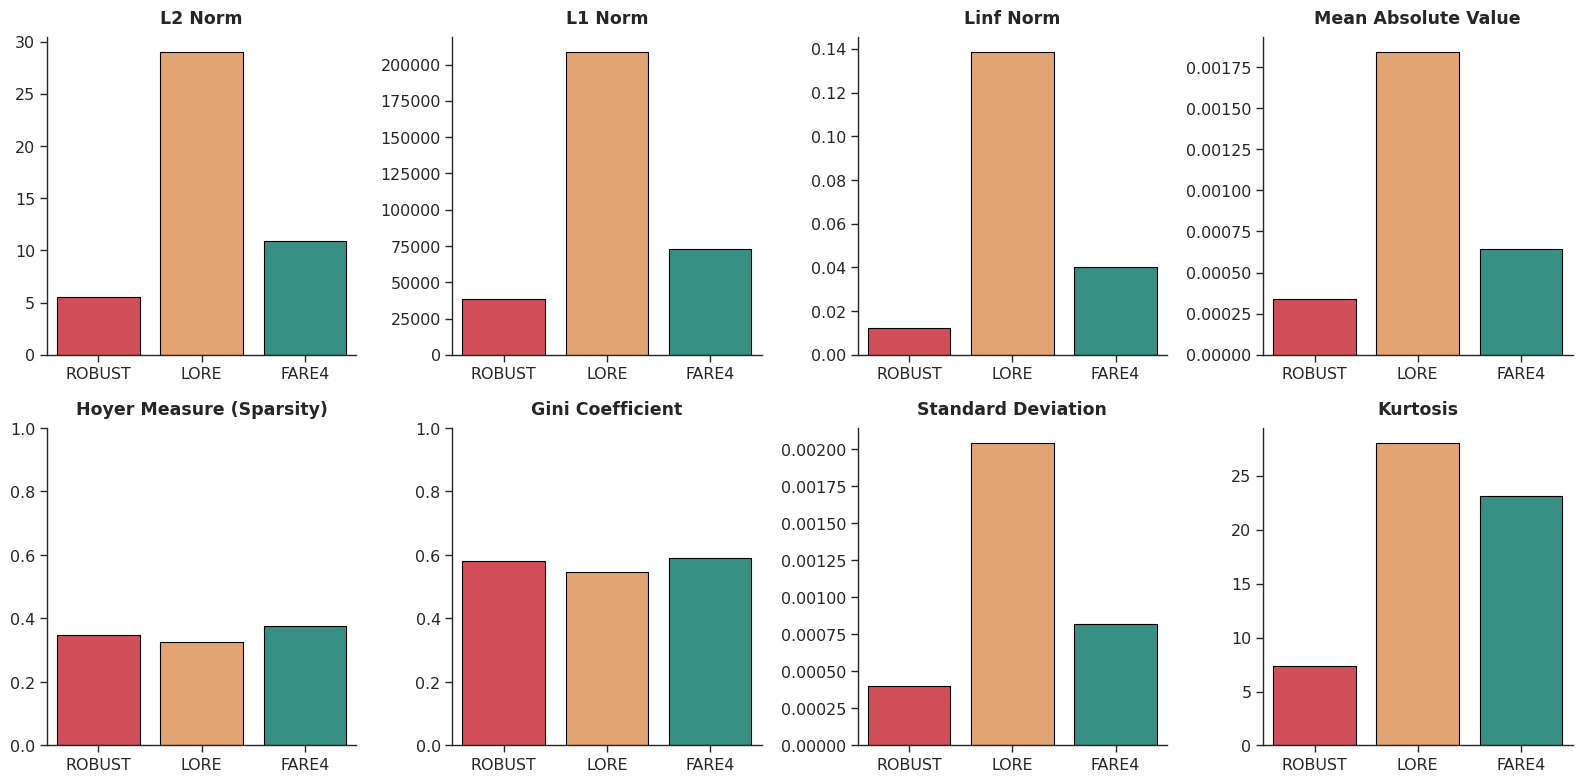

In [20]:
plot_rv_comparison(all_vectors[('robust', 'ViT-B-32', 'ImageNet100', 1)], lore_vector, fare_vector, labels=('ROBUST', 'LORE', 'FARE4'))



/tmp/ipykernel_178135/1713348563.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


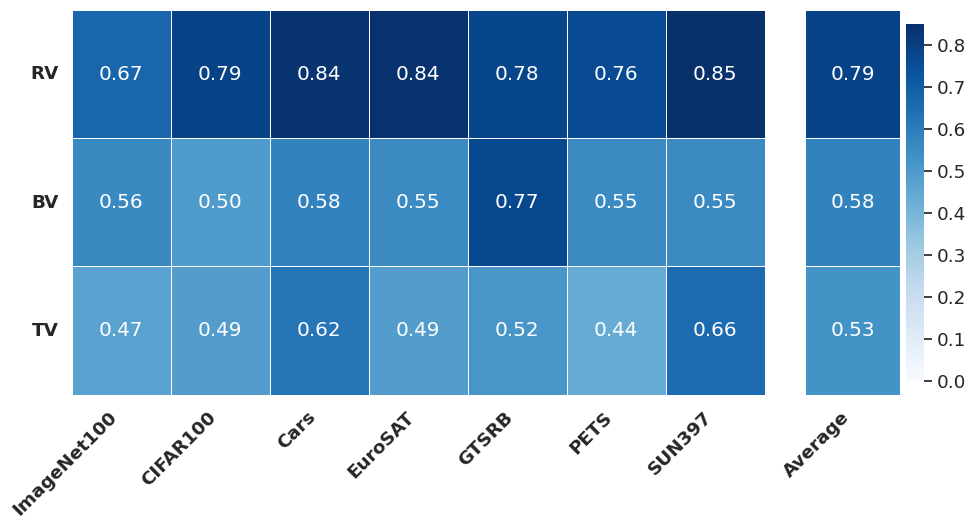

In [10]:
def plot_vector_stability_heatmap(all_vectors, models, datasets, vector_types, seeds, save_path='stability_heatmap.pdf'):
    model = models[0] 
    sim_matrix = np.zeros((len(vector_types), len(datasets)))

    label_map = {
        'robust': 'RV',
        'backdoor': 'BV',
        'task': 'TV'
    }
    
    for i, v_type in enumerate(vector_types):
        for j, dataset in enumerate(datasets):
            
            # 1. Zbieramy wektory dla wszystkich seedów w ramach tej komórki
            vecs = []
            for seed in seeds:
                key = (v_type, model, dataset, seed)
                if key in all_vectors:
                    vecs.append(all_vectors[key])
            
            similarities = []
            # 2. Generujemy wszystkie unikalne pary wektorów (cross-seed)
            for v1, v2 in itertools.combinations(vecs, 2):
                cos_sim = torch.nn.functional.cosine_similarity(
                    v1.unsqueeze(0), v2.unsqueeze(0)
                ).item()
                similarities.append(cos_sim)
            
            # 3. Uśredniamy wyniki dla komórki
            if similarities:
                sim_matrix[i, j] = np.mean(similarities)
            else:
                sim_matrix[i, j] = np.nan
                
    # --- OBLICZANIE ŚREDNIEJ DLA KAŻDEGO WIERSZA ---
    # Używamy np.nanmean, żeby zignorować ewentualne braki danych (komórki z NaN)
    row_means = np.nanmean(sim_matrix, axis=1, keepdims=True)
                
    # ==========================================
    # RYSOWANIE W STYLU CVPR (Z ODDZIELNĄ KOLUMNĄ)
    # ==========================================
    sns.set_theme(style="white", font_scale=1.2)
    
    # Tworzymy 2 podwykresy:
    # ax_main: Główna macierz
    # ax_avg: Pojedyncza kolumna na średnie + miejsce na pasek kolorów (dlatego 1.2)
    # wspace=0.1 to fizyczna odległość (przerwa) między obiema macierzami
    fig, (ax_main, ax_avg) = plt.subplots(1, 2, figsize=(11, 5), 
                                          gridspec_kw={'width_ratios': [len(datasets), 1.2], 'wspace': 0.1}) 
    
    row_labels = [label_map.get(v, v.capitalize()) for v in vector_types]
    
    # --- GŁÓWNY HEATMAP ---
    # Wyłączamy cbar=False, żeby pasek kolorów nie pojawił się dwa razy
    sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=datasets, yticklabels=row_labels,
                linewidths=0.5, linecolor='white',
                vmin=0.0, vmax=0.85, cbar=False, ax=ax_main)
                
    # --- HEATMAP ŚREDNICH ---
    # Wyłączamy yticklabels=False, bo mamy już etykiety po lewej stronie głównego wykresu
    sns.heatmap(row_means, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=['Average'], yticklabels=False, 
                linewidths=0.5, linecolor='white',
                vmin=0.0, vmax=0.85, cbar=True, ax=ax_avg)
                     
    # Formatowanie osi dla GŁÓWNEGO wykresu
    ax_main.set_xticklabels(ax_main.get_xticklabels(), rotation=45, ha='right', fontweight='bold')
    ax_main.set_yticklabels(ax_main.get_yticklabels(), rotation=0, fontweight='bold')
    
    # Formatowanie osi dla wykresu ze ŚREDNIĄ
    ax_avg.set_xticklabels(ax_avg.get_xticklabels(), rotation=45, ha='right', fontweight='bold')
    ax_avg.tick_params(left=False) # Usuwamy niepotrzebne małe kreseczki na osi Y
    
    plt.tight_layout()
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()

plot_vector_stability_heatmap(all_vectors, MODELS, DATASETS, VECTOR_TYPES, SEEDS, save_path='./results/fig_4_seeds.pdf')


In [ ]:
matrix_total = None
seeds = [1]

# for seed in seeds:
# task_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'task' and k[3] == seed}
# task_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'backdoor' and k[3] == seed}
task_vectors = {k: v for k, v in all_vectors.items() if k[0] == 'robust' and (k[3] == 1 or k[1] in ('FARE4', 'LORE4'))}
if matrix_total is None:
    matrix_total = calculate_cossim_matrix_with_baselines(task_vectors, sparsity_k=0.1)
else:
    matrix_total += calculate_cossim_matrix_with_baselines(task_vectors, sparsity_k=0.1)

final_matrix = matrix_total / len(seeds)
plot_heatmap(final_matrix, './results/cossim_matrix_robust.png', labels=[k[1] for k in task_vectors.keys()])


TypeError: object of type 'int' has no len()

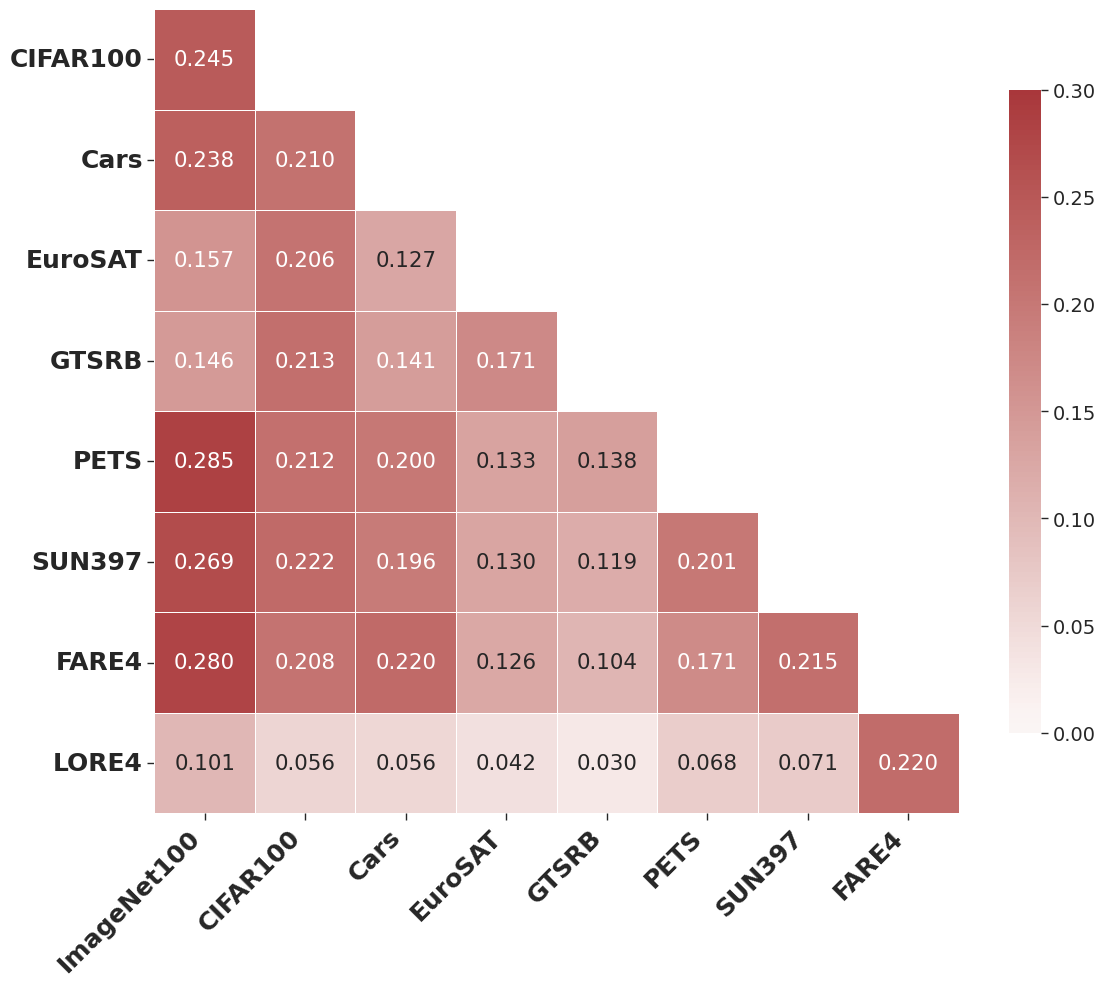

In [17]:
plot_heatmap(matrix_total, './results/cossim_matrix_robust.png')


In [6]:
def apply_topk_mask(v, k):
    if k is None:
        return v
    n = v.numel()
    k_int = int(n * k) if isinstance(k, float) else k
    threshold = torch.topk(v.abs(), k_int).values.min()
    return v * (v.abs() >= threshold).float()


def calculate_cossim_matrix_with_baselines(vector_dict: dict, seed: int = 42, sparsity_k: float = None) -> pd.DataFrame:
    labels = [f"{k[2]}" for k in vector_dict.keys()]

    vectors = []
    for v in vector_dict.values():
        vectors.append(apply_topk_mask(v, sparsity_k))

    num_vecs = len(vectors)
    mean_norm = torch.stack([v.norm() for v in vectors]).mean()

    # Baseline gaussian
    rng = torch.Generator()
    rng.manual_seed(seed)
    noise = torch.randn(vectors[0].shape, generator=rng)
    noise = apply_topk_mask(noise, sparsity_k)
    
    gaussian_vec = noise * (mean_norm / (noise.norm() + 1e-8))

    # Shuffle
    shuffle_vecs = []
    for i, vec in enumerate(vectors):
        rng_i = torch.Generator()
        rng_i.manual_seed(seed + i)
        perm = torch.randperm(vec.numel(), generator=rng_i)
        shuffle_vecs.append(vec.flatten()[perm].reshape(vec.shape))

    all_labels = labels
    # all_labels = labels + ['noise', 'shuffle']
    all_vecs   = vectors
    # all_vecs   = vectors + [gaussian_vec, None]
    n = len(all_labels)
    matrix = pd.DataFrame(index=all_labels, columns=all_labels, dtype=float)

    for i in range(n):
        for j in range(n):
            la, va = all_labels[i], all_vecs[i]
            lb, vb = all_labels[j], all_vecs[j]

            if i == j:
                matrix.iloc[i, j] = 1.0

            elif la == 'shuffle' and lb == 'shuffle':
                # shuffle vs shuffle - średnia po przekątnej (każdy ze swoim)
                matrix.iloc[i, j] = np.mean([
                    F.cosine_similarity(shuffle_vecs[k].unsqueeze(0), 
                                        shuffle_vecs[k].unsqueeze(0)).item()
                    for k in range(num_vecs)
                ])

            elif la == 'shuffle':
                if j < num_vecs:  # tylko dla oryginalnych wektorów
                    matrix.iloc[i, j] = F.cosine_similarity(
                        vectors[j].unsqueeze(0),
                        shuffle_vecs[j].unsqueeze(0)
                    ).item()
                else:
                    matrix.iloc[i, j] = 0.0

            elif lb == 'shuffle':
                if i < num_vecs:  # tylko dla oryginalnych wektorów
                    matrix.iloc[i, j] = F.cosine_similarity(
                        vectors[i].unsqueeze(0),
                        shuffle_vecs[i].unsqueeze(0)
                    ).item()
                else:
                    matrix.iloc[i, j] = 0.0  # baseline vs baseline shuffle = 0

            else:
                matrix.iloc[i, j] = F.cosine_similarity(
                    va.unsqueeze(0), vb.unsqueeze(0)
                ).item()

    return matrix

In [8]:
def calculate_cossim_matrix(vector_dict: dict) -> np.array:
    labels = [f"{k[0]} {k[2]} (s:{k[3]})" for k in vector_dict.keys()]
    vectors = list(vector_dict.values())
    num_vecs = len(vectors)

    matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)

    for i in range(num_vecs):
        for j in range(num_vecs):
            if i == j:
                matrix.iloc[i, j] = 1.0
            else:
                sim = F.cosine_similarity(vectors[i].unsqueeze(0), vectors[j].unsqueeze(0))
                matrix.iloc[i, j] = sim.item()

    return matrix


def plot_heatmap(matrix, title: str = None) -> None:
    if not isinstance(matrix, pd.DataFrame):
        matrix = pd.DataFrame(matrix)
        
    matrix = matrix.iloc[1:, :-1]

    plt.figure(figsize=(12, 10))
    sns.set_theme(style="ticks", context="paper", font_scale=1.6)
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

    sns.heatmap(
        matrix, 
        mask=mask,
        annot=True,
        cmap='vlag',
        center=0,
        vmin=-0, vmax=0.3,
        fmt=".3f",
        linewidths=.5,
        cbar_kws={"shrink": .8},
        square=True 
    )

    plt.xticks(rotation=45, ha='right', fontsize=18, fontweight='bold')
    plt.yticks(rotation=0, fontsize=18, fontweight='bold')
    
    sns.despine(left=True, bottom=True)
    
    plt.savefig(title, format='pdf', bbox_inches='tight')
    plt.tight_layout()
    # plt.show()


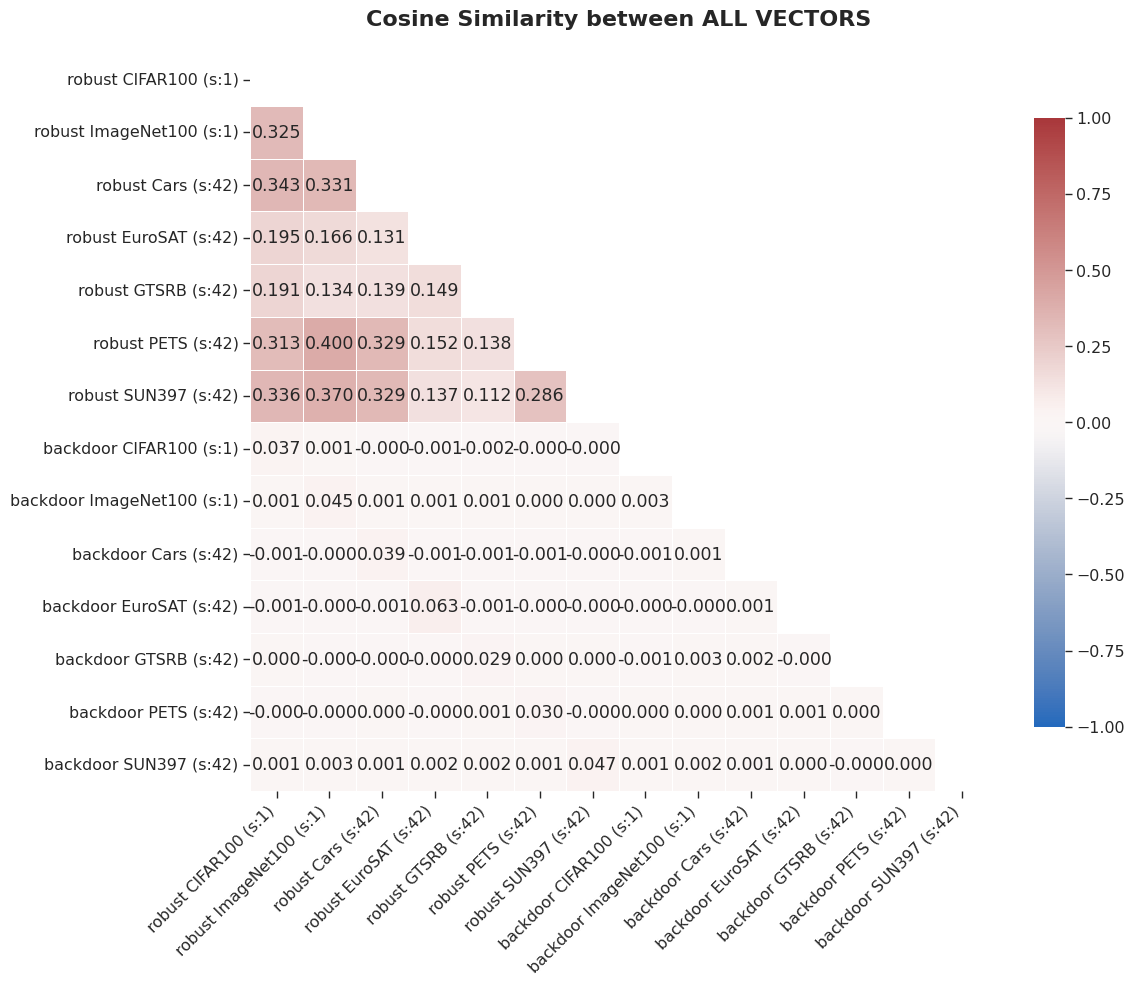

In [ ]:
matrix = calculate_cossim_matrix(all_basic_vectors)
plot_heatmap(matrix, 'ALL VECTORS')



In [11]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

def compute_basic_stats(all_vectors):
    records = []
    
    for (v_type, model, dataset, seed), vec in all_vectors.items():
        v = vec.float()
        
        # === NORMS ===
        l2   = torch.norm(v, p=2).item()
        l1   = torch.norm(v, p=1).item()
        linf = torch.norm(v, p=float('inf')).item()
        
        # === SPARSITY ===
        n = v.numel()
        hoyer = (np.sqrt(n) - (l1 / (l2 + 1e-12))) / (np.sqrt(n) - 1 + 1e-12)
        abs_v = v.abs()
        
        # Gini coefficient
        sorted_v = abs_v.sort().values
        idx = torch.arange(1, n + 1, dtype=torch.float32)
        gini = (2 * (idx * sorted_v).sum() / (n * sorted_v.sum() + 1e-12) - (n + 1) / n).item()
        
        # Mean / Std / Kurtosis
        mean_abs = abs_v.mean().item()
        std_abs  = abs_v.std().item()
        kurt = (((v - v.mean()) / (v.std() + 1e-12)) ** 4).mean().item() - 3
        
        records.append({
            'v_type'  : v_type,
            'model'   : model,
            'dataset' : dataset,
            'seed'    : seed,

            'l2'      : l2,
            'l1'      : l1,
            'linf'    : linf,
            'l1_l2'   : l1 / (l2 + 1e-12),

            'hoyer'   : hoyer,
            'gini'    : gini,
            'mean_abs': mean_abs,
            'std_abs' : std_abs,
            'kurtosis': kurt,
        })
    
    return pd.DataFrame(records)


In [12]:
df_stats = compute_basic_stats(all_basic_vectors)


In [13]:
df_stats

,v_type,model,dataset,seed,l2,l1,linf,l1_l2,hoyer,gini,mean_abs,std_abs,kurtosis
0,robust,ViT-B-32,ImageNet100,1,5.532812,38462.136719,0.012179,6951.643976,0.347371,0.580435,0.000339,0.000402,7.377171
1,robust,FARE4,FARE4,1,10.937091,72746.945312,0.040276,6651.398087,0.375563,0.590592,0.000642,0.000819,23.128780
2,robust,LORE4,LORE4,1,28.958326,208343.437500,0.138393,7194.595263,0.324560,0.546971,0.001838,0.002040,28.036148


In [14]:
def plot_rv_comparison(robust_vec, lore_vec, fare_vec, labels=('Robust', 'LORE', 'FARE')):
    
    vectors_dict = {
        (labels[0], labels[0], labels[0], 0): robust_vec,
        (labels[1], labels[1], labels[1], 0): lore_vec,
        (labels[2], labels[2], labels[2], 0): fare_vec,
    }
    
    df = compute_basic_stats(vectors_dict)

    metrics = {
        'l2': 'L2 Norm', 'l1': 'L1 Norm', 'linf': 'Linf Norm',
        'mean_abs': 'Mean Absolute Value', 'hoyer': 'Hoyer Measure (Sparsity)',
        'gini': 'Gini Coefficient', 'std_abs': 'Standard Deviation', 'kurtosis': 'Kurtosis'
    }

    palette = {labels[0]: "#E63946", labels[1]: "#F4A261", labels[2]: "#2A9D8F"}

    sns.set_theme(style="ticks", context="paper", font_scale=1.3)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, (col, title) in enumerate(metrics.items()):
        ax = axes[i]
        sns.barplot(
            data=df, x='v_type', y=col,
            ax=ax, palette=palette,
            edgecolor='black', linewidth=0.8,
        )
        if col in ['gini', 'hoyer']:
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(bottom=0)
        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('')
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2650460/1907996864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2650460/1907996864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2650460/1907996864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2650460/1907996864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2650460/1907996864.py:29: Fut

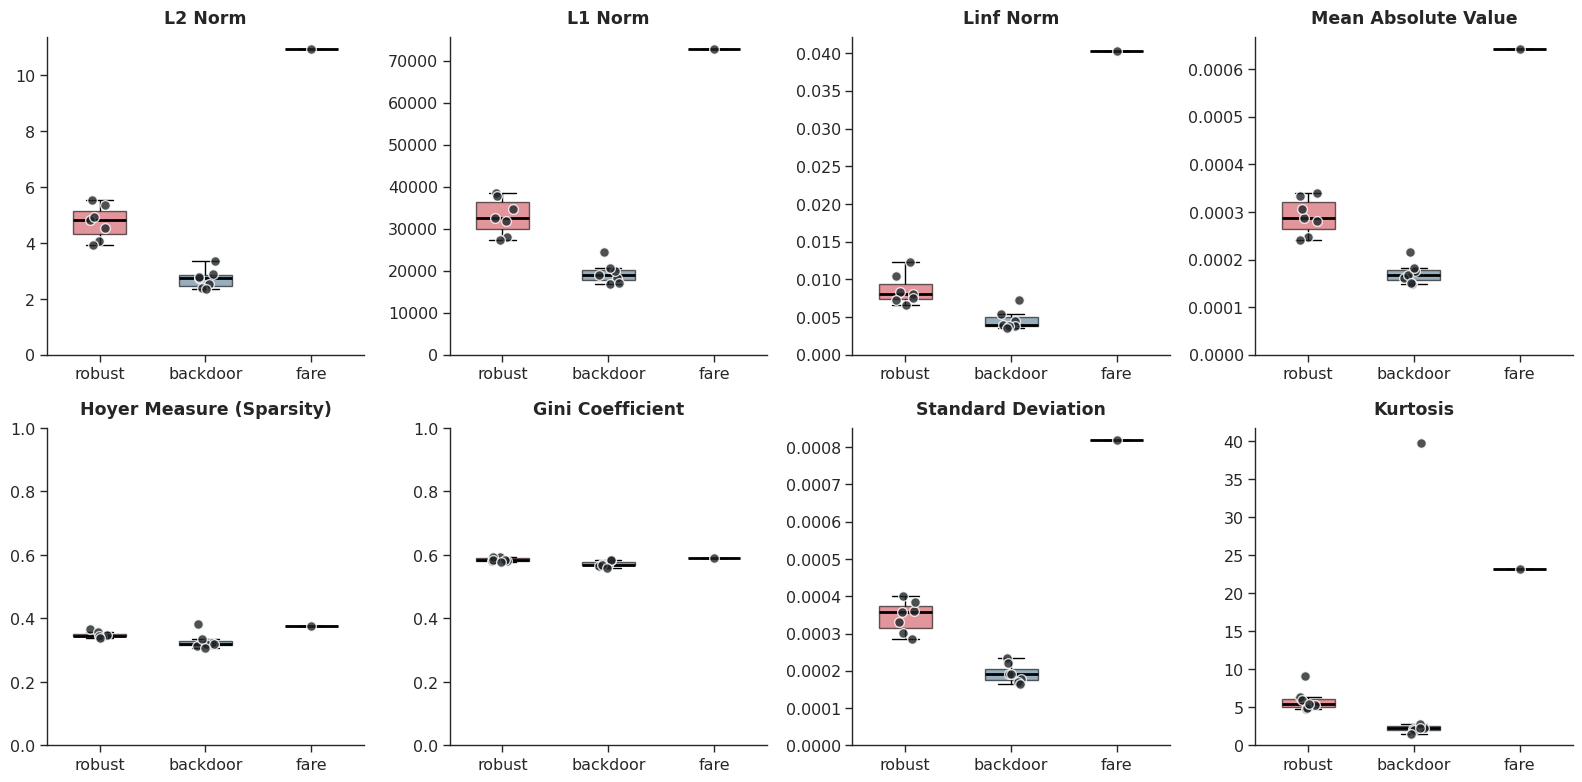

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Konfiguracja stylu publikacyjnego
sns.set_theme(style="ticks", context="paper", font_scale=1.3)

# 2. Słownik metryk z ładnymi nazwami do tytułów
metrics = {
    'l2': 'L2 Norm',
    'l1': 'L1 Norm',
    'linf': 'Linf Norm',
    'mean_abs': 'Mean Absolute Value',
    'hoyer': 'Hoyer Measure (Sparsity)',
    'gini': 'Gini Coefficient',
    'std_abs': 'Standard Deviation',
    'kurtosis': 'Kurtosis'
}

# 3. Tworzymy siatkę wykresów 2x4
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {"robust": "#E63946", "backdoor": "#457B9D", "fare": "#2A9D8F"} 

for i, (col, title) in enumerate(metrics.items()):
    ax = axes[i]
    
    # Boxplot
    sns.boxplot(
        data=df_stats, x='v_type', y=col, 
        ax=ax, width=0.5, palette=palette, 
        boxprops=dict(alpha=0.6, edgecolor='black'), 
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        medianprops=dict(color='black', linewidth=2),
        showfliers=False
    )
    
    # Stripplot
    sns.stripplot(
        data=df_stats, x='v_type', y=col, 
        ax=ax, size=7, color="#212529", alpha=0.8, jitter=True, edgecolor='white', linewidth=1
    )
    
    # KLUCZOWA ZMIANA: Zakotwiczenie osi Y na zerze
    ax.set_ylim(bottom=0)
    
    # Opcjonalnie: Dla metryk, które mają twardy limit górny (np. Gini i Hoyer od 0 do 1), 
    # możesz odkomentować poniższy kod, żeby pokazać pełną skalę 0-1:
    if col in ['gini', 'hoyer']:
        ax.set_ylim(0, 1)

    # Oczyszczanie osi i tytuły
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Minimalizm naukowy
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

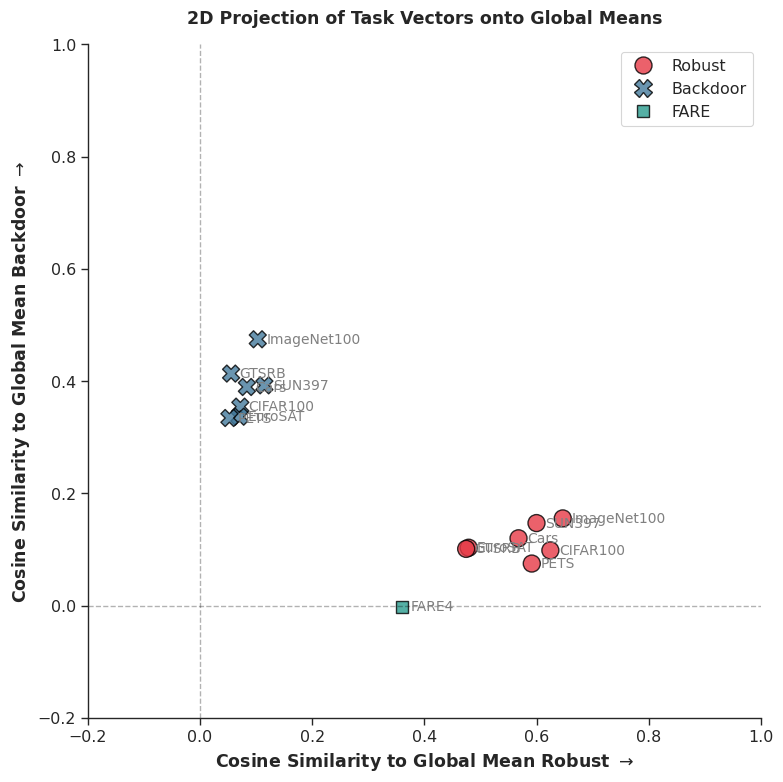

In [13]:
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wyciągamy wszystkie wektory ze słownika (założenie: masz słownik all_vectors)
robust_keys = [k for k in robust_vectors.keys() if k[0] == 'robust']
backdoor_keys = [k for k in backdoor_vectors.keys() if k[0] == 'backdoor']

# 2. Obliczamy nasze "Osie Współrzędnych" (Global Means)
# Używamy torch.stack by połączyć je w macierz i wyciągamy średnią po wymiarze 0
global_mean_robust = torch.stack([robust_vectors[k] for k in robust_keys]).mean(dim=0)
global_mean_backdoor = torch.stack([backdoor_vectors[k] for k in backdoor_keys]).mean(dim=0)

# 3. Rzutujemy każdy pojedynczy wektor na nasze nowe osie
projection_data = []

for key in all_basic_vectors.keys():
    v_type, model, dataset, seed = key
    vec = all_basic_vectors[key]
    
    # Rzutowanie (projekcja) za pomocą Cosine Similarity
    x_val = F.cosine_similarity(vec.unsqueeze(0), global_mean_robust.unsqueeze(0)).item()
    y_val = F.cosine_similarity(vec.unsqueeze(0), global_mean_backdoor.unsqueeze(0)).item()
    
    projection_data.append({
        'Type': 'Robust' if v_type == 'robust' else 'Backdoor' if v_type == 'backdoor' else 'FARE',
        'Dataset': dataset,
        'Similarity to Mean Robust (X)': x_val,
        'Similarity to Mean Backdoor (Y)': y_val
    })

df_proj = pd.DataFrame(projection_data)

# 4. Rysujemy piękny wykres punktowy (Scatter Plot)
plt.figure(figsize=(10, 8))
sns.set_theme(style="ticks", context="paper", font_scale=1.3)

# Rysujemy punkty z wyraźnym rozróżnieniem kolorów i stylów
sns.scatterplot(
    data=df_proj, 
    x='Similarity to Mean Robust (X)', 
    y='Similarity to Mean Backdoor (Y)', 
    hue='Type', 
    style='Type',
    palette={"Robust": "#E63946", "Backdoor": "#457B9D", "FARE": "#2A9D8F"},
    s=150,           # Wielkość punktów
    edgecolor='black', 
    linewidth=1,
    alpha=0.8
)

# Dodajemy podpisy datasetów do każdego punktu
for i in range(df_proj.shape[0]):
    plt.text(
        df_proj['Similarity to Mean Robust (X)'][i] + 0.015, 
        df_proj['Similarity to Mean Backdoor (Y)'][i], 
        df_proj['Dataset'][i], 
        horizontalalignment='left', 
        verticalalignment='center',
        fontsize=10,
        color='gray'
    )

# 5. Kosmetyka i formatowanie do publikacji
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.3) # Linia zera dla Y
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.3) # Linia zera dla X

plt.title("2D Projection of Task Vectors onto Global Means", fontweight='bold', pad=15)
plt.xlabel("Cosine Similarity to Global Mean Robust $\\rightarrow$", fontweight='bold')
plt.ylabel("Cosine Similarity to Global Mean Backdoor $\\rightarrow$", fontweight='bold')

# Wymuszamy równe proporcje osi, żeby wizualnie nie zakłamać odległości
plt.xlim(-0.2, 1.0)
plt.ylim(-0.2, 1.0)
plt.gca().set_aspect('equal', adjustable='box')

sns.despine()
plt.legend(title="", loc='upper right', frameon=True)
plt.tight_layout()

# plt.savefig("vector_2d_projection.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

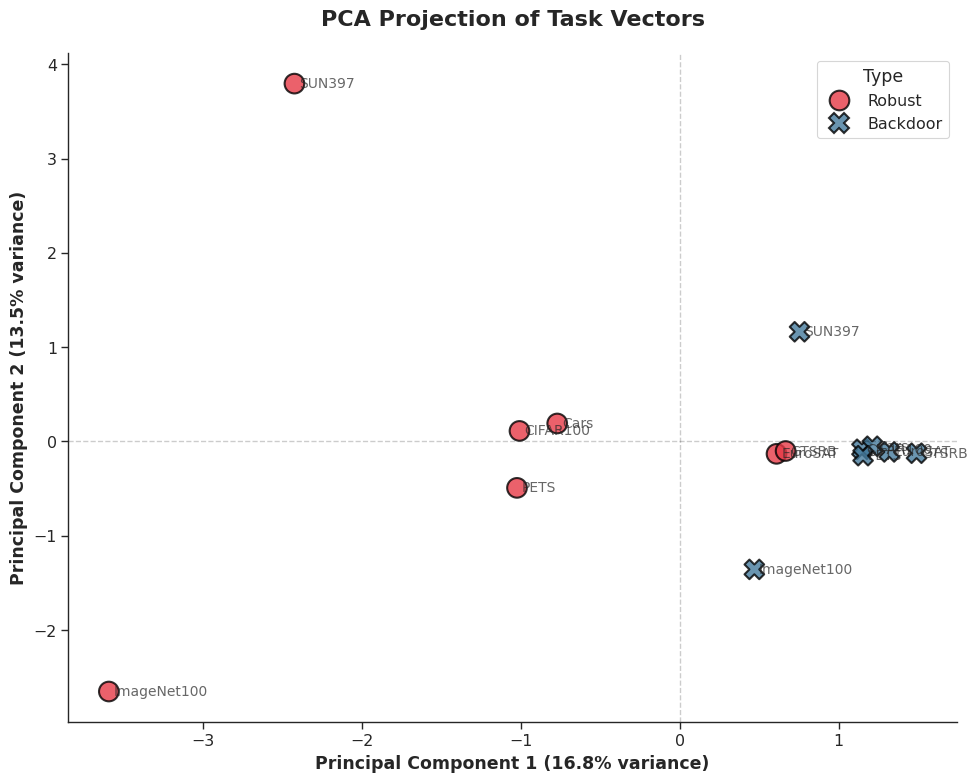

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

# 1. Przygotowanie macierzy danych (N wektorów x D wymiarów)
keys = list(all_basic_vectors.keys())
# Zamieniamy słownik na tensor i od razu na numpy dla sklearn
data_matrix = torch.stack([all_basic_vectors[k] for k in keys]).cpu().numpy()

# 2. Wykonujemy PCA (2 komponenty)
# Skalowanie nie zawsze jest konieczne przy wektorach wag, ale pomaga w PCA
pca = PCA(n_components=2)
components = pca.fit_transform(data_matrix)

# 3. Tworzymy DataFrame do wizualizacji
df_pca = pd.DataFrame(components, columns=['PC1', 'PC2'])
df_pca['Type'] = ['Robust' if k[0] == 'robust' else 'Backdoor' for k in keys]
df_pca['Dataset'] = [k[2] for k in keys]

# Procent wyjaśnionej wariancji (ważne do opisu wykresu!)
exp_var = pca.explained_variance_ratio_ * 100

# 4. Wykres PCA
plt.figure(figsize=(10, 8))
sns.set_theme(style="ticks", context="paper", font_scale=1.3)

sns.scatterplot(
    data=df_pca, 
    x='PC1', y='PC2', 
    hue='Type', style='Type',
    markers={"Robust": "o", "Backdoor": "X"},
    palette={"Robust": "#E63946", "Backdoor": "#457B9D"},
    s=200, edgecolor='black', linewidth=1.5, alpha=0.8
)

# Podpisy datasetów
for i in range(len(df_pca)):
    plt.text(
        df_pca.PC1[i] + (df_pca.PC1.max()*0.02), 
        df_pca.PC2[i], 
        df_pca.Dataset[i], 
        fontsize=10, alpha=0.7, va='center'
    )

plt.title("PCA Projection of Task Vectors", fontweight='bold', size=16, pad=20)
plt.xlabel(f"Principal Component 1 ({exp_var[0]:.1f}% variance)", fontweight='bold')
plt.ylabel(f"Principal Component 2 ({exp_var[1]:.1f}% variance)", fontweight='bold')

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.2)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()

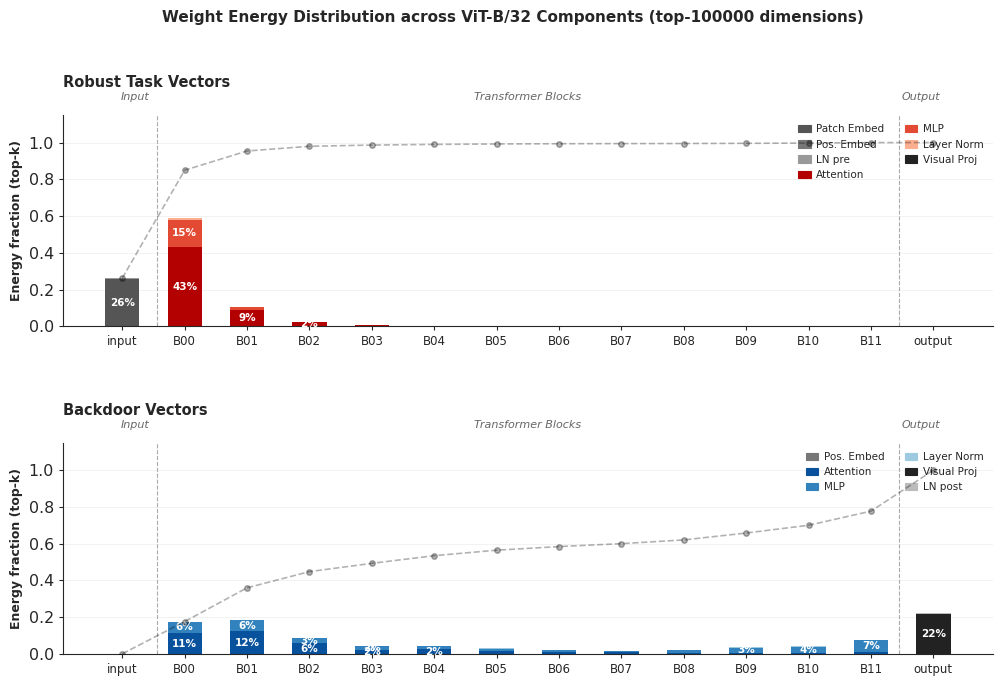

In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from collections import defaultdict
import numpy as np
import torch
import pandas as pd

def plot_layer_attribution_publication(all_vectors, raw_state_dict_path, k=1000):
    # --- 1. WCZYTYWANIE DANYCH ---
    raw_sd = torch.load(raw_state_dict_path, map_location='cpu', weights_only=False)
    idx2layer = build_index_to_layer(raw_sd)
    keys = list(all_vectors.keys())

    def categorize(name):
        if 'patch_embed' in name: return ('input', 'patch_embed')
        if 'cls_token'   in name: return ('input', 'cls_token')
        if 'pos_embed'   in name: return ('input', 'pos_embed')
        if 'ln_pre'      in name: return ('input', 'ln_pre')
        if 'visual_proj' in name: return ('output', 'visual_proj')
        if 'ln_post'     in name: return ('output', 'ln_post')
        if 'text'        in name: return ('text', name)
        if 'block_'      in name:
            try:
                block_num = int(name.split('_')[1].split('.')[0])
                sub = ('attn' if 'attn' in name else
                       'mlp'  if 'mlp'  in name else 'ln')
                return (f'B{block_num:02d}', sub)
            except: pass
        return ('other', name)

    # --- 2. POPRAWIONA AGREGACJA (Gwarancja sumy = 1.0) ---
    v_types = ['robust', 'backdoor']
    keys_per_type = {vt: [k_ for k_ in keys if k_[0] == vt] for vt in v_types}
    
    records = []
    for v_type in v_types:
        t_keys = keys_per_type[v_type]
        if not t_keys: continue
        
        # Słownik pilnujący zer dla modeli, które nie modyfikują danej warstwy
        model_sums = {key: defaultdict(lambda: defaultdict(float)) for key in t_keys}
        
        for key in t_keys:
            vec = all_vectors[key].float()
            topk_vals, topk_idx = torch.topk(vec.abs(), k)
            total = topk_vals.sum().item()
            for idx, val in zip(topk_idx.tolist(), topk_vals.tolist()):
                g, s = categorize(simplify_layer_name(idx2layer[idx]))
                model_sums[key][g][s] += val / total

        # Zbieranie unikalnych grup
        all_gs = set()
        for key in t_keys:
            for g in model_sums[key]:
                for s in model_sums[key][g]:
                    all_gs.add((g, s))
                    
        # Uśrednianie
        for g, s in all_gs:
            vals = [model_sums[key][g][s] for key in t_keys]
            records.append({
                'v_type': v_type, 'group': g, 'sub': s, 'mean': np.mean(vals)
            })
            
    df = pd.DataFrame(records)

    group_order = (['input'] + [f'B{b:02d}' for b in range(12)] + ['output'])
    sub_order   = ['patch_embed','pos_embed','ln_pre','attn','mlp','ln','visual_proj','ln_post']

    # ── Style z Twojego projektu ─────────────────────────────────────────────
    plt.rcParams.update({
        'font.family':      'DejaVu Sans',
        'font.size':        9,
        'axes.linewidth':   0.8,
        'axes.spines.top':  False,
        'axes.spines.right':False,
        'xtick.major.size': 3,
        'ytick.major.size': 3,
        'xtick.major.width':0.8,
        'ytick.major.width':0.8,
    })

    PALETTE = {
        # ROBUST - Dominanta: Czyste czerwienie + Profesjonalne szarości
        ('robust', 'patch_embed'): '#555555',  # Ciemny szary
        ('robust', 'pos_embed'):   '#777777',  # Średni szary
        ('robust', 'ln_pre'):      '#999999',  # Jasny szary
        ('robust', 'attn'):        '#B30000',  # Głęboka, mocna czerwień
        ('robust', 'mlp'):         '#E34A33',  # Jasna, żywa czerwień
        ('robust', 'ln'):          '#FCAE91',  # Bardzo jasny czerwony (prawie pastelowy)
        ('robust', 'visual_proj'): '#222222',  # Prawie czarny (silny akcent na wyjściu)
        ('robust', 'ln_post'):     '#BBBBBB',  # Szary

        # BACKDOOR - Dominanta: Czyste błękity + Profesjonalne szarości
        ('backdoor', 'patch_embed'): '#555555',  # (Te same szarości co wyżej)
        ('backdoor', 'pos_embed'):   '#777777',  
        ('backdoor', 'ln_pre'):      '#999999',  
        ('backdoor', 'attn'):        '#08519C',  # Głęboki, mocny niebieski
        ('backdoor', 'mlp'):         '#3182BD',  # Jasny, żywy niebieski
        ('backdoor', 'ln'):          '#9ECAE1',  # Bardzo jasny niebieski (prawie pastelowy)
        ('backdoor', 'visual_proj'): '#222222',  # Prawie czarny
        ('backdoor', 'ln_post'):     '#BBBBBB',  
    }

    sub_labels  = {
        'patch_embed': 'Patch Embed', 'pos_embed': 'Pos. Embed',
        'ln_pre': 'LN pre',           'attn': 'Attention',
        'mlp': 'MLP',                 'ln': 'Layer Norm',
        'visual_proj': 'Visual Proj', 'ln_post': 'LN post',
    }

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'hspace': 0.55})

    type_titles = {'robust': 'Robust Task Vectors', 'backdoor': 'Backdoor Vectors'}

    for ax, v_type in zip(axes, ['robust', 'backdoor']):
        sub_df = df[df['v_type'] == v_type]
        
        # Filtrujemy tylko te grupy, które faktycznie mają jakieś dane
        present = [g for g in group_order if g in sub_df['group'].values]
        
        x = np.arange(len(present))
        bottoms = np.zeros(len(present))
        legend_handles = []

        for sub in sub_order:
            heights = np.array([sub_df[(sub_df['group'] == g) & (sub_df['sub'] == sub)]['mean'].values[0] 
                               if len(sub_df[(sub_df['group'] == g) & (sub_df['sub'] == sub)]) else 0.0 
                               for g in present])
            
            if heights.max() < 1e-4: continue

            color = PALETTE.get((v_type, sub), '#AAAAAA')
            ax.bar(x, heights, bottom=bottoms, color=color, width=0.55, linewidth=0, label=sub_labels[sub])

            # Adnotacje słupków (pokazujemy jako procenty bez miejsc po przecinku)
            for i, (h, b) in enumerate(zip(heights, bottoms)):
                if h > 0.02:  # Pokazuj tylko jeśli warstwa zabiera więcej niż 2% energii
                    text_color = 'white' if sub != 'ln' else 'black'
                    ax.text(i, b + h / 2, f'{h*100:.0f}%', ha='center', va='center',
                            fontsize=7.5, color=text_color, fontweight='bold')

            legend_handles.append(mpatches.Patch(color=color, label=sub_labels[sub]))
            bottoms += heights

        # --- DODANA LINIA SKUMULOWANEJ ENERGII ---
        cumulative_energy = np.cumsum(bottoms)
        ax.plot(x, cumulative_energy, color='black', marker='o', linestyle='--', 
                linewidth=1.2, markersize=4, zorder=10, alpha=0.3)
        
        # if len(x) > 0:
        #     ax.text(x[-1], cumulative_energy[-1] + 0.03, f'{cumulative_energy[-1]*100:.0f}%', 
        #             ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')

        # --- DELIKATNE PODPISY SEKCJI I LINIE PODZIAŁU ---
        block_indices = [i for i, g in enumerate(present) if g.startswith('B')]
        if block_indices:
            # Rysujemy pionowe linie przerywane
            ax.axvline(block_indices[0] - 0.45, color='#AAAAAA', lw=0.8, ls='--', zorder=0)
            ax.axvline(block_indices[-1] + 0.45, color='#AAAAAA', lw=0.8, ls='--', zorder=0)

            # Rysujemy teksty z użyciem transformacji osi X
            mid_block = (block_indices[0] + block_indices[-1]) / 2
            for label, xi in [('Input', block_indices[0] - 0.8),
                              ('Transformer Blocks', mid_block),
                              ('Output', block_indices[-1] + 0.8)]:
                ax.text(xi, 1.06, label, transform=ax.get_xaxis_transform(),
                        ha='center', va='bottom', fontsize=8, color='#666666', style='italic')

        # Estetyka osi
        ax.set_xticks(x)
        ax.set_xticklabels(present, fontsize=8.5)
        ax.set_ylabel('Energy fraction (top-k)', fontsize=9, fontweight='bold')
        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.set_title(type_titles[v_type], fontsize=10.5, fontweight='bold', pad=20, loc='left')
        ax.grid(axis='y', linewidth=0.5, alpha=0.35, zorder=0)

        # Legenda w prawym górnym rogu (według życzenia)
        ax.legend(handles=legend_handles, fontsize=7.5, loc='upper right', 
                  frameon=False, ncol=2, handlelength=1.2, handletextpad=0.5)

    fig.suptitle(f'Weight Energy Distribution across ViT-B/32 Components (top-{k} dimensions)',
                 fontsize=11, fontweight='bold', y=1.03)

    plt.savefig('layer_attribution_pub_final.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# RUN
plot_layer_attribution_publication(all_basic_vectors, RAW_SD_PATH, k=100000)

ValueError: zero-size array to reduction operation maximum which has no identity

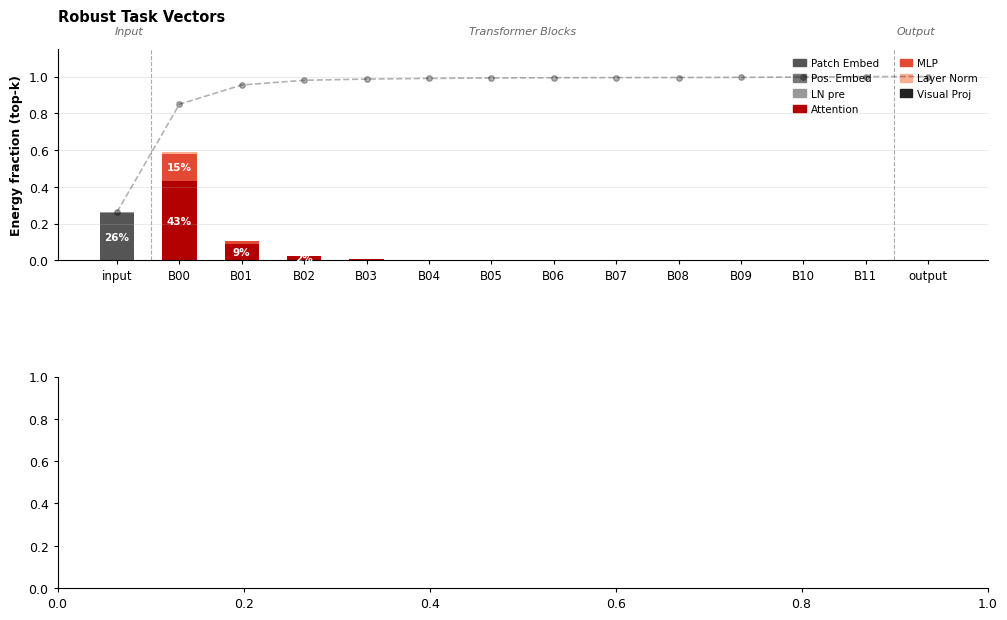

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from collections import defaultdict
import numpy as np
import torch
import pandas as pd

def plot_layer_attribution_publication(all_vectors, raw_state_dict_path, k=1000):
    # --- 1. WCZYTYWANIE DANYCH ---
    raw_sd = torch.load(raw_state_dict_path, map_location='cpu', weights_only=False)
    idx2layer = build_index_to_layer(raw_sd)
    keys = list(all_vectors.keys())

    def categorize(name):
        if 'patch_embed' in name: return ('input', 'patch_embed')
        if 'cls_token'   in name: return ('input', 'cls_token')
        if 'pos_embed'   in name: return ('input', 'pos_embed')
        if 'ln_pre'      in name: return ('input', 'ln_pre')
        if 'visual_proj' in name: return ('output', 'visual_proj')
        if 'ln_post'     in name: return ('output', 'ln_post')
        if 'text'        in name: return ('text', name)
        if 'block_'      in name:
            try:
                block_num = int(name.split('_')[1].split('.')[0])
                sub = ('attn' if 'attn' in name else
                       'mlp'  if 'mlp'  in name else 'ln')
                return (f'B{block_num:02d}', sub)
            except: pass
        return ('other', name)

    # --- 2. POPRAWIONA AGREGACJA (Gwarancja sumy = 1.0) ---
    v_types = ['robust', 'fare']
    keys_per_type = {vt: [k_ for k_ in keys if k_[0] == vt] for vt in v_types}
    
    records = []
    for v_type in v_types:
        t_keys = keys_per_type[v_type]
        if not t_keys: continue
        
        # Słownik pilnujący zer dla modeli, które nie modyfikują danej warstwy
        model_sums = {key: defaultdict(lambda: defaultdict(float)) for key in t_keys}
        
        for key in t_keys:
            vec = all_vectors[key].float()
            topk_vals, topk_idx = torch.topk(vec.abs(), k)
            total = topk_vals.sum().item()
            for idx, val in zip(topk_idx.tolist(), topk_vals.tolist()):
                g, s = categorize(simplify_layer_name(idx2layer[idx]))
                model_sums[key][g][s] += val / total

        # Zbieranie unikalnych grup
        all_gs = set()
        for key in t_keys:
            for g in model_sums[key]:
                for s in model_sums[key][g]:
                    all_gs.add((g, s))
                    
        # Uśrednianie
        for g, s in all_gs:
            vals = [model_sums[key][g][s] for key in t_keys]
            records.append({
                'v_type': v_type, 'group': g, 'sub': s, 'mean': np.mean(vals)
            })
            
    df = pd.DataFrame(records)

    group_order = (['input'] + [f'B{b:02d}' for b in range(12)] + ['output'])
    sub_order   = ['patch_embed','pos_embed','ln_pre','attn','mlp','ln','visual_proj','ln_post']

    # ── Style z Twojego projektu ─────────────────────────────────────────────
    plt.rcParams.update({
        'font.family':      'DejaVu Sans',
        'font.size':        9,
        'axes.linewidth':   0.8,
        'axes.spines.top':  False,
        'axes.spines.right':False,
        'xtick.major.size': 3,
        'ytick.major.size': 3,
        'xtick.major.width':0.8,
        'ytick.major.width':0.8,
    })

    PALETTE = {
        # ROBUST - Dominanta: Czyste czerwienie + Profesjonalne szarości
        ('robust', 'patch_embed'): '#555555',  # Ciemny szary
        ('robust', 'pos_embed'):   '#777777',  # Średni szary
        ('robust', 'ln_pre'):      '#999999',  # Jasny szary
        ('robust', 'attn'):        '#B30000',  # Głęboka, mocna czerwień
        ('robust', 'mlp'):         '#E34A33',  # Jasna, żywa czerwień
        ('robust', 'ln'):          '#FCAE91',  # Bardzo jasny czerwony (prawie pastelowy)
        ('robust', 'visual_proj'): '#222222',  # Prawie czarny (silny akcent na wyjściu)
        ('robust', 'ln_post'):     '#BBBBBB',  # Szary

        ('fare', 'patch_embed'): '#555555',
        ('fare', 'pos_embed'):   '#777777',
        ('fare', 'ln_pre'):      '#999999',
        ('fare', 'attn'):        '#005F4E',  # Głęboka zieleń
        ('fare', 'mlp'):         '#2A9D8F',  # Żywa zieleń
        ('fare', 'ln'):          '#8ECFC0',  # Pastelowa zieleń
        ('fare', 'visual_proj'): '#222222',
        ('fare', 'ln_post'):     '#BBBBBB',
    }

    sub_labels  = {
        'patch_embed': 'Patch Embed', 'pos_embed': 'Pos. Embed',
        'ln_pre': 'LN pre',           'attn': 'Attention',
        'mlp': 'MLP',                 'ln': 'Layer Norm',
        'visual_proj': 'Visual Proj', 'ln_post': 'LN post',
    }

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'hspace': 0.55})

    type_titles = {'robust': 'Robust Task Vectors', 'fare': 'FARE Robust Vector'}

    for ax, v_type in zip(axes, ['robust', 'backdoor']):
        sub_df = df[df['v_type'] == v_type]
        
        # Filtrujemy tylko te grupy, które faktycznie mają jakieś dane
        present = [g for g in group_order if g in sub_df['group'].values]
        
        x = np.arange(len(present))
        bottoms = np.zeros(len(present))
        legend_handles = []

        for sub in sub_order:
            heights = np.array([sub_df[(sub_df['group'] == g) & (sub_df['sub'] == sub)]['mean'].values[0] 
                               if len(sub_df[(sub_df['group'] == g) & (sub_df['sub'] == sub)]) else 0.0 
                               for g in present])
            
            if heights.max() < 1e-4: continue

            color = PALETTE.get((v_type, sub), '#AAAAAA')
            ax.bar(x, heights, bottom=bottoms, color=color, width=0.55, linewidth=0, label=sub_labels[sub])

            # Adnotacje słupków (pokazujemy jako procenty bez miejsc po przecinku)
            for i, (h, b) in enumerate(zip(heights, bottoms)):
                if h > 0.02:  # Pokazuj tylko jeśli warstwa zabiera więcej niż 2% energii
                    text_color = 'white' if sub != 'ln' else 'black'
                    ax.text(i, b + h / 2, f'{h*100:.0f}%', ha='center', va='center',
                            fontsize=7.5, color=text_color, fontweight='bold')

            legend_handles.append(mpatches.Patch(color=color, label=sub_labels[sub]))
            bottoms += heights

        # --- DODANA LINIA SKUMULOWANEJ ENERGII ---
        cumulative_energy = np.cumsum(bottoms)
        ax.plot(x, cumulative_energy, color='black', marker='o', linestyle='--', 
                linewidth=1.2, markersize=4, zorder=10, alpha=0.3)
        
        # if len(x) > 0:
        #     ax.text(x[-1], cumulative_energy[-1] + 0.03, f'{cumulative_energy[-1]*100:.0f}%', 
        #             ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')

        # --- DELIKATNE PODPISY SEKCJI I LINIE PODZIAŁU ---
        block_indices = [i for i, g in enumerate(present) if g.startswith('B')]
        if block_indices:
            # Rysujemy pionowe linie przerywane
            ax.axvline(block_indices[0] - 0.45, color='#AAAAAA', lw=0.8, ls='--', zorder=0)
            ax.axvline(block_indices[-1] + 0.45, color='#AAAAAA', lw=0.8, ls='--', zorder=0)

            # Rysujemy teksty z użyciem transformacji osi X
            mid_block = (block_indices[0] + block_indices[-1]) / 2
            for label, xi in [('Input', block_indices[0] - 0.8),
                              ('Transformer Blocks', mid_block),
                              ('Output', block_indices[-1] + 0.8)]:
                ax.text(xi, 1.06, label, transform=ax.get_xaxis_transform(),
                        ha='center', va='bottom', fontsize=8, color='#666666', style='italic')

        # Estetyka osi
        ax.set_xticks(x)
        ax.set_xticklabels(present, fontsize=8.5)
        ax.set_ylabel('Energy fraction (top-k)', fontsize=9, fontweight='bold')
        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.set_title(type_titles[v_type], fontsize=10.5, fontweight='bold', pad=20, loc='left')
        ax.grid(axis='y', linewidth=0.5, alpha=0.35, zorder=0)

        # Legenda w prawym górnym rogu (według życzenia)
        ax.legend(handles=legend_handles, fontsize=7.5, loc='upper right', 
                  frameon=False, ncol=2, handlelength=1.2, handletextpad=0.5)

    fig.suptitle(f'Weight Energy Distribution across ViT-B/32 Components (top-{k} dimensions)',
                 fontsize=11, fontweight='bold', y=1.03)

    plt.savefig('layer_attribution_pub_final.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# RUN
plot_layer_attribution_publication(all_basic_vectors, RAW_SD_PATH, k=100000)

In [ ]:
def build_index_to_layer(raw_state_dict):
    """
    raw_state_dict: oryginalny state_dict (przed spłaszczeniem)
    Zwraca: lista stringów długości d, gdzie d = dim wektora
    """
    index_to_layer = []
    for name, param in raw_state_dict.items():
        index_to_layer.extend([name] * param.numel())
    return index_to_layer  # len == d


def simplify_layer_name(name):
    """
    ViT-B/32 naming → czytelny blok
    np. 'visual.transformer.resblocks.5.attn.in_proj_weight' → 'block_05.attn'
    """
    if 'resblocks' in name:
        parts = name.split('.')
        try:
            rb_idx = parts.index('resblocks')
            block_num = int(parts[rb_idx + 1])
            remainder = parts[rb_idx + 2] if rb_idx + 2 < len(parts) else ''
            # attn vs mlp
            if 'attn' in remainder or 'in_proj' in name or 'out_proj' in name:
                sub = 'attn'
            elif 'mlp' in remainder or 'c_fc' in name or 'c_proj' in name:
                sub = 'mlp'
            elif 'ln' in remainder:
                sub = f'ln_{remainder}'
            else:
                sub = remainder
            return f'block_{block_num:02d}.{sub}'
        except (ValueError, IndexError):
            pass
    if 'ln_pre' in name:  return 'ln_pre'
    if 'ln_post' in name: return 'ln_post'
    if 'conv1' in name:   return 'patch_embed'
    if 'class_embedding' in name: return 'cls_token'
    if 'positional_embedding' in name: return 'pos_embed'
    if 'proj' in name and 'visual' in name: return 'visual_proj'
    if 'text' in name:    return 'text_encoder'
    return name.split('.')[-2] if '.' in name else name

RAW_SD_PATH = './vectors/robust/ViT-B-32/Cars/vector.pt'

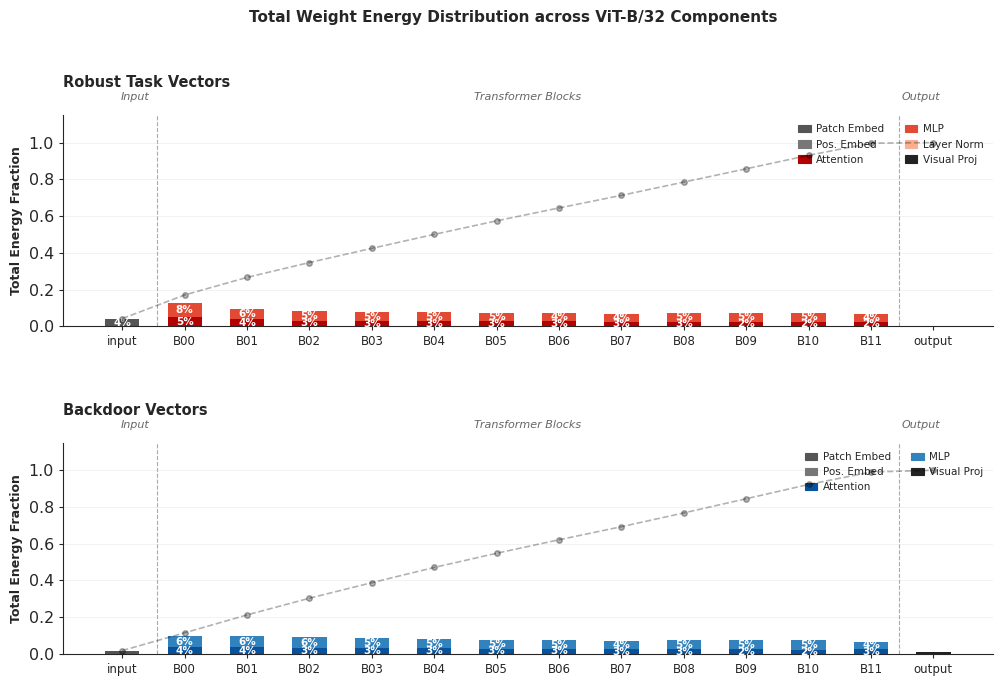

In [71]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from collections import defaultdict
import numpy as np
import torch
import pandas as pd

def plot_layer_attribution_full_energy(all_vectors, raw_state_dict_path):
    # --- 1. WCZYTYWANIE DANYCH ---
    raw_sd = torch.load(raw_state_dict_path, map_location='cpu', weights_only=False)
    idx2layer = build_index_to_layer(raw_sd)
    keys = list(all_vectors.keys())

    def categorize(name):
        if 'patch_embed' in name: return ('input', 'patch_embed')
        if 'cls_token'   in name: return ('input', 'cls_token')
        if 'pos_embed'   in name: return ('input', 'pos_embed')
        if 'ln_pre'      in name: return ('input', 'ln_pre')
        if 'visual_proj' in name: return ('output', 'visual_proj')
        if 'ln_post'     in name: return ('output', 'ln_post')
        if 'text'        in name: return ('text', name)
        if 'block_'      in name:
            try:
                block_num = int(name.split('_')[1].split('.')[0])
                sub = ('attn' if 'attn' in name else
                       'mlp'  if 'mlp'  in name else 'ln')
                return (f'B{block_num:02d}', sub)
            except: pass
        return ('other', name)

    # --- 2. AGREGACJA PEŁNEJ ENERGII (BEZ TOP-K) ---
    v_types = ['robust', 'backdoor']
    keys_per_type = {vt: [k_ for k_ in keys if k_[0] == vt] for vt in v_types}
    
    records = []
    for v_type in v_types:
        t_keys = keys_per_type[v_type]
        if not t_keys: continue
        
        model_sums = {key: defaultdict(lambda: defaultdict(float)) for key in t_keys}
        
        for key in t_keys:
            # Pobieramy absolutne wartości CAŁEGO wektora
            vec_abs = all_vectors[key].float().abs()
            total_energy = vec_abs.sum().item()
            
            # Aby uniknąć wolnej iteracji po milionach elementów w Pythonie,
            # grupujemy indeksy należące do tych samych warstw.
            # UWAGA: Zakładamy, że funkcja build_index_to_layer to obsługuje
            # (albo można to zoptymalizować na poziomie tensora)
            for idx, val in enumerate(vec_abs.tolist()):
                 g, s = categorize(simplify_layer_name(idx2layer[idx]))
                 model_sums[key][g][s] += val / total_energy

        # Zbieranie unikalnych grup
        all_gs = set()
        for key in t_keys:
            for g in model_sums[key]:
                for s in model_sums[key][g]:
                    all_gs.add((g, s))
                    
        # Uśrednianie wyników dla danego typu wektora
        for g, s in all_gs:
            vals = [model_sums[key][g][s] for key in t_keys]
            records.append({
                'v_type': v_type, 'group': g, 'sub': s, 'mean': np.mean(vals)
            })
            
    df = pd.DataFrame(records)

    group_order = (['input'] + [f'B{b:02d}' for b in range(12)] + ['output'])
    sub_order   = ['patch_embed','pos_embed','ln_pre','attn','mlp','ln','visual_proj','ln_post']

    # ── Style z Twojego projektu ─────────────────────────────────────────────
    plt.rcParams.update({
        'font.family':      'DejaVu Sans',
        'font.size':        9,
        'axes.linewidth':   0.8,
        'axes.spines.top':  False,
        'axes.spines.right':False,
        'xtick.major.size': 3,
        'ytick.major.size': 3,
        'xtick.major.width':0.8,
        'ytick.major.width':0.8,
    })

    PALETTE = {
        ('robust', 'patch_embed'): '#555555',  ('robust', 'pos_embed'):   '#777777',  
        ('robust', 'ln_pre'):      '#999999',  ('robust', 'attn'):        '#B30000',  
        ('robust', 'mlp'):         '#E34A33',  ('robust', 'ln'):          '#FCAE91',  
        ('robust', 'visual_proj'): '#222222',  ('robust', 'ln_post'):     '#BBBBBB',  

        ('backdoor', 'patch_embed'): '#555555',  ('backdoor', 'pos_embed'):   '#777777',  
        ('backdoor', 'ln_pre'):      '#999999',  ('backdoor', 'attn'):        '#08519C',  
        ('backdoor', 'mlp'):         '#3182BD',  ('backdoor', 'ln'):          '#9ECAE1',  
        ('backdoor', 'visual_proj'): '#222222',  ('backdoor', 'ln_post'):     '#BBBBBB',  
    }

    sub_labels  = {
        'patch_embed': 'Patch Embed', 'pos_embed': 'Pos. Embed',
        'ln_pre': 'LN pre',           'attn': 'Attention',
        'mlp': 'MLP',                 'ln': 'Layer Norm',
        'visual_proj': 'Visual Proj', 'ln_post': 'LN post',
    }

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'hspace': 0.55})

    type_titles = {'robust': 'Robust Task Vectors', 'backdoor': 'Backdoor Vectors'}

    for ax, v_type in zip(axes, ['robust', 'backdoor']):
        sub_df = df[df['v_type'] == v_type]
        
        present = [g for g in group_order if g in sub_df['group'].values]
        
        x = np.arange(len(present))
        bottoms = np.zeros(len(present))
        legend_handles = []

        for sub in sub_order:
            heights = np.array([sub_df[(sub_df['group'] == g) & (sub_df['sub'] == sub)]['mean'].values[0] 
                               if len(sub_df[(sub_df['group'] == g) & (sub_df['sub'] == sub)]) else 0.0 
                               for g in present])
            
            if heights.max() < 1e-4: continue

            color = PALETTE.get((v_type, sub), '#AAAAAA')
            ax.bar(x, heights, bottom=bottoms, color=color, width=0.55, linewidth=0, label=sub_labels[sub])

            for i, (h, b) in enumerate(zip(heights, bottoms)):
                if h > 0.02:  
                    text_color = 'white' if sub != 'ln' else 'black'
                    ax.text(i, b + h / 2, f'{h*100:.0f}%', ha='center', va='center',
                            fontsize=7.5, color=text_color, fontweight='bold')

            legend_handles.append(mpatches.Patch(color=color, label=sub_labels[sub]))
            bottoms += heights

        # Linia skumulowanej energii
        cumulative_energy = np.cumsum(bottoms)
        ax.plot(x, cumulative_energy, color='black', marker='o', linestyle='--', 
                linewidth=1.2, markersize=4, zorder=10, alpha=0.3)

        # Delikatne podpisy sekcji
        block_indices = [i for i, g in enumerate(present) if g.startswith('B')]
        if block_indices:
            ax.axvline(block_indices[0] - 0.45, color='#AAAAAA', lw=0.8, ls='--', zorder=0)
            ax.axvline(block_indices[-1] + 0.45, color='#AAAAAA', lw=0.8, ls='--', zorder=0)

            mid_block = (block_indices[0] + block_indices[-1]) / 2
            for label, xi in [('Input', block_indices[0] - 0.8),
                              ('Transformer Blocks', mid_block),
                              ('Output', block_indices[-1] + 0.8)]:
                ax.text(xi, 1.06, label, transform=ax.get_xaxis_transform(),
                        ha='center', va='bottom', fontsize=8, color='#666666', style='italic')

        ax.set_xticks(x)
        ax.set_xticklabels(present, fontsize=8.5)
        ax.set_ylabel('Total Energy Fraction', fontsize=9, fontweight='bold')
        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.set_title(type_titles[v_type], fontsize=10.5, fontweight='bold', pad=20, loc='left')
        ax.grid(axis='y', linewidth=0.5, alpha=0.35, zorder=0)

        ax.legend(handles=legend_handles, fontsize=7.5, loc='upper right', 
                  frameon=False, ncol=2, handlelength=1.2, handletextpad=0.5)

    # Zmiana tytułu głównego (bez adnotacji 'top-k')
    fig.suptitle(f'Total Weight Energy Distribution across ViT-B/32 Components',
                 fontsize=11, fontweight='bold', y=1.03)

    plt.savefig('layer_attribution_pub_full_energy.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# RUN (Bez parametru k)
plot_layer_attribution_full_energy(all_basic_vectors, RAW_SD_PATH)